In [4]:
R"""""
Lab 6: Visualize Attention Heatmaps in Seq2Seq Models
Clean implementation with attention mechanism and visualization
"""""

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout,
    Concatenate, Flatten, Layer, Softmax, Permute, RepeatVector
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("LAB 6: ATTENTION HEATMAPS IN SEQ2SEQ")
print("=" * 60)

# ===== CUSTOM ATTENTION LAYER =====
class AttentionLayer(Layer):
    """Bahdanau Attention Layer"""
    def __init__(self, units=64, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        self.units = units
        self.W1 = Dense(units, use_bias=False)
        self.W2 = Dense(units, use_bias=False)
        self.b = tf.Variable(tf.zeros([units]))
        self.V = Dense(1, use_bias=False)

    def call(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: [batch, units]
        encoder_outputs: [batch, seq_len, units]
        """
        # Expand decoder hidden for broadcasting
        decoder_hidden = tf.expand_dims(decoder_hidden, 1)  # [batch, 1, units]

        # Calculate attention scores
        score = self.V(tf.nn.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden)))
        # score shape: [batch, seq_len, 1]

        # Calculate attention weights
        attention_weights = tf.nn.softmax(score, axis=1)  # [batch, seq_len, 1]

        # Calculate context vector
        context = tf.reduce_sum(attention_weights * encoder_outputs, axis=1)

        return context, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config


# ===== SIMPLE DATA PREPARATION =====
print("\n" + "-" * 60)
print("Preparing Data")
print("-" * 60)

# English to French simple phrases
source_texts = [
    "hello world",
    "good morning",
    "thank you",
    "how are you",
    "good night",
    "see you later",
    "what is this",
    "i love python"
]

target_texts = [
    "bonjour monde",
    "bon matin",
    "merci",
    "comment allez-vous",
    "bonne nuit",
    "a bientot",
    "qu est ce",
    "j aime python"
]

# Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

source_tokenizer = Tokenizer(char_level=True)
source_tokenizer.fit_on_texts(source_texts)
source_sequences = source_tokenizer.texts_to_sequences(source_texts)
source_padded = pad_sequences(source_sequences, maxlen=15, padding='post')

target_tokenizer = Tokenizer(char_level=True)
target_tokenizer.fit_on_texts(target_texts)
target_sequences = target_tokenizer.texts_to_sequences(target_texts)
target_padded = pad_sequences(target_sequences, maxlen=15, padding='post')

source_vocab_size = len(source_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

print(f"Source vocab size: {source_vocab_size}")
print(f"Target vocab size: {target_vocab_size}")
print(f"Source sequences shape: {source_padded.shape}")
print(f"Target sequences shape: {target_padded.shape}")

# ===== SEQ2SEQ WITH ATTENTION =====
print("\n" + "-" * 60)
print("Building Seq2Seq with Attention")
print("-" * 60)

# Encoder
encoder_inputs = Input(shape=(15,), name="encoder_input")
encoder_embedding = Embedding(source_vocab_size, 64, name="encoder_embedding")(encoder_inputs)
encoder_lstm = LSTM(128, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

print(f"Encoder output shape: {encoder_outputs.shape}")

# Decoder
decoder_inputs = Input(shape=(15,), name="decoder_input")
decoder_embedding = Embedding(target_vocab_size, 64, name="decoder_embedding")(decoder_inputs)
decoder_lstm = LSTM(128, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

# Attention
attention = AttentionLayer(units=128, name="attention")
context, attention_weights = attention(decoder_outputs[:, -1, :], encoder_outputs)

# Concatenate context with decoder outputs
repeated_context = RepeatVector(15)(context)
decoder_combined = Concatenate()([decoder_outputs, repeated_context])

# Output layer
decoder_dense = Dense(target_vocab_size, activation='softmax', name="output_dense")
final_outputs = decoder_dense(decoder_combined)

# Seq2Seq with Attention Model
model = Model([encoder_inputs, decoder_inputs], final_outputs)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "-" * 60)
print("Model Summary:")
print("-" * 60)
model.summary()

# ===== TRAINING =====
print("\n" + "-" * 60)
print("Training Model")
print("-" * 60)

target_padded_expanded = np.expand_dims(target_padded, -1)

history = model.fit(
    [source_padded, target_padded],
    target_padded_expanded,
    epochs=150,
    batch_size=2,
    validation_split=0.25,
    verbose=0
)

print(f"Training completed!")
print(f"Final accuracy: {history.history['accuracy'][-1]:.4f}")

# ===== CREATE INFERENCE MODELS FOR ATTENTION VISUALIZATION =====
print("\n" + "-" * 60)
print("Creating Inference Models for Attention Visualization")
print("-" * 60)

# Encoder inference model
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])

# Decoder inference model with attention
decoder_state_input_h = Input(shape=(128,), name="decoder_state_h")
decoder_state_input_c = Input(shape=(128,), name="decoder_state_c")
encoder_seq_inputs = Input(shape=(15, 128), name="encoder_seq")

decoder_lstm_inf = LSTM(128, return_sequences=True, return_state=True)
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm_inf(
    decoder_embedding,
    initial_state=[decoder_state_input_h, decoder_state_input_c]
)

# Attention for inference
decoder_hidden_inp = Input(shape=(128,), name="decoder_hidden")
context_inf, attn_weights_inf = attention(decoder_hidden_inp, encoder_seq_inputs)

# ===== ATTENTION VISUALIZATION =====
print("\n" + "-" * 60)
print("Visualizing Attention Heatmaps")
print("-" * 60)

# Create visualization model
viz_encoder_inputs = Input(shape=(15,), name="viz_encoder_input")
viz_encoder_embedding = Embedding(source_vocab_size, 64)(viz_encoder_inputs)
viz_encoder_lstm = LSTM(128, return_sequences=True, return_state=True)
viz_encoder_outputs, viz_state_h, viz_state_c = viz_encoder_lstm(viz_encoder_embedding)

viz_decoder_inputs = Input(shape=(15,), name="viz_decoder_input")
viz_decoder_embedding = Embedding(target_vocab_size, 64)(viz_decoder_inputs)
viz_decoder_lstm = LSTM(128, return_sequences=True, return_state=True)
viz_decoder_outputs, _, _ = viz_decoder_lstm(viz_decoder_embedding, initial_state=[viz_state_h, viz_state_c])

viz_attention = AttentionLayer(units=128)
viz_context, viz_attn_weights = viz_attention(viz_decoder_outputs[:, -1, :], viz_encoder_outputs)

viz_model = Model([viz_encoder_inputs, viz_decoder_inputs], [viz_decoder_outputs, viz_attn_weights])

# Get attention weights for sample
sample_idx = 0
sample_source = source_padded[sample_idx:sample_idx+1]
sample_target = target_padded[sample_idx:sample_idx+1]

_, attn_weights = viz_model.predict([sample_source, sample_target], verbose=0)
attn_weights = attn_weights.squeeze()

# Ensure proper shape for heatmap (2D: time_steps x 1)
if attn_weights.ndim == 1:
    attn_weights = attn_weights.reshape(-1, 1)

print(f"Attention weights shape: {attn_weights.shape}")
print(f"Sample source text: {source_texts[sample_idx]}")
print(f"Sample target text: {target_texts[sample_idx]}")

# ===== CREATE VISUALIZATIONS =====
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training History - Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training', linewidth=2, color='#2E86AB')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#A23B72')
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Training History - Loss
axes[0, 1].plot(history.history['loss'], label='Training', linewidth=2, color='#2E86AB')
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2, color='#A23B72')
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Attention Heatmap
source_tokens = list(source_texts[sample_idx].replace(' ', '|'))
# Get the actual length of the source sequence, excluding padding
actual_source_len = len(source_sequences[sample_idx])
# Slice attn_weights to match the actual length of source tokens
attn_weights_for_heatmap = attn_weights[:actual_source_len]

sns.heatmap(attn_weights_for_heatmap,
            xticklabels=['Attention'],
            yticklabels=source_tokens,
            cmap='YlOrRd',
            annot=True,
            fmt='.2f',
            cbar_kws={'label': 'Attention Weight'},
            ax=axes[1, 0])
axes[1, 0].set_title(f'Attention Heatmap\n"{source_texts[sample_idx]}" → "{target_texts[sample_idx]}"',
                     fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Attention', fontsize=11)
axes[1, 0].set_ylabel('Source Tokens', fontsize=11)

# 4. Attention Distribution
attn_sum = np.sum(attn_weights_for_heatmap, axis=1) if attn_weights_for_heatmap.ndim > 1 else attn_weights_for_heatmap
axes[1, 1].bar(range(len(source_tokens)), attn_sum[:len(source_tokens)], color='#F18F01', alpha=0.8)
# Add mean line to the attention distribution plot
mean_attention_for_sample = np.mean(attn_sum)
axes[1, 1].axhline(mean_attention_for_sample, color='red', linestyle='--', label=f'Mean Attention: {mean_attention_for_sample:.2f}')
axes[1, 1].set_xticks(range(len(source_tokens)))
axes[1, 1].set_xticklabels(source_tokens, rotation=45, ha='right')
axes[1, 1].set_title('Total Attention per Source Token', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Source Tokens', fontsize=11)
axes[1, 1].set_ylabel('Attention Sum', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/lab6_attention_heatmaps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lab6_attention_heatmaps.png")
plt.close()

# ===== ADDITIONAL ATTENTION ANALYSIS =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Multiple attention heatmaps
for idx, ax in enumerate(axes):
    if idx < 2:
        sample_source = source_padded[idx:idx+1]
        sample_target = target_padded[idx:idx+1]
        _, attn_w = viz_model.predict([sample_source, sample_target], verbose=0)
        attn_w = attn_w.squeeze()

        # Ensure proper shape
        if attn_w.ndim == 1:
            attn_w = attn_w.reshape(-1, 1)

        source_tokens = list(source_texts[idx].replace(' ', '|'))
        # Get the actual length of the source sequence for the current sample
        actual_source_len = len(source_sequences[idx])
        # Slice attn_w to match the actual length of source tokens
        attn_w_for_heatmap = attn_w[:actual_source_len]


        sns.heatmap(attn_w_for_heatmap,
                    xticklabels=['Attention'],
                    yticklabels=source_tokens,
                    cmap='viridis',
                    annot=True,
                    fmt='.2f',
                    cbar_kws={'label': 'Weight'},
                    ax=ax)
        ax.set_title(f'"{source_texts[idx]}" → "{target_texts[idx]}"',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Attention', fontsize=10)
        ax.set_ylabel('Source', fontsize=10)

plt.tight_layout()
plt.savefig('/content/lab6_multiple_attention.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lab6_multiple_attention.png")
plt.close()

print("\n" + "=" * 60)
print("LAB 6 COMPLETED SUCCESSFULLY")
print("=" * 60)


LAB 6: ATTENTION HEATMAPS IN SEQ2SEQ

------------------------------------------------------------
Preparing Data
------------------------------------------------------------
Source vocab size: 21
Target vocab size: 24
Source sequences shape: (8, 15)
Target sequences shape: (8, 15)

------------------------------------------------------------
Building Seq2Seq with Attention
------------------------------------------------------------
Encoder output shape: (None, 15, 128)

------------------------------------------------------------
Model Summary:
------------------------------------------------------------


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 15, 64)    │      1,344 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 15, 64)    │      1,536 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 15, 128), │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 15, 128), │     98,816 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 128)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, 128),     │     32,896 │ get_item_6[0][0], │
│ (AttentionLayer)    │ (None, 15, 1)]    │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_3     │ (None, 15, 128)   │          0 │ attention[0][0]   │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 15, 256)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 15, 24)    │      6,168 │ concatenate_3[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 239,576 (935.84 KB)

 Trainable params: 239,576 (935.84 KB)

 Non-trainable params: 0 (0.00 B)


------------------------------------------------------------
Training Model
------------------------------------------------------------
Training completed!
Final accuracy: 1.0000

------------------------------------------------------------
Creating Inference Models for Attention Visualization
------------------------------------------------------------

------------------------------------------------------------
Visualizing Attention Heatmaps
------------------------------------------------------------
Attention weights shape: (15, 1)
Sample source text: hello world
Sample target text: bonjour monde

Generating visualizations...
✓ Saved: lab6_attention_heatmaps.png
✓ Saved: lab6_multiple_attention.png

LAB 6 COMPLETED SUCCESSFULLY



------------------------------------------------------------
Displaying Visualizations
------------------------------------------------------------
### Combined Attention Heatmap and Distribution


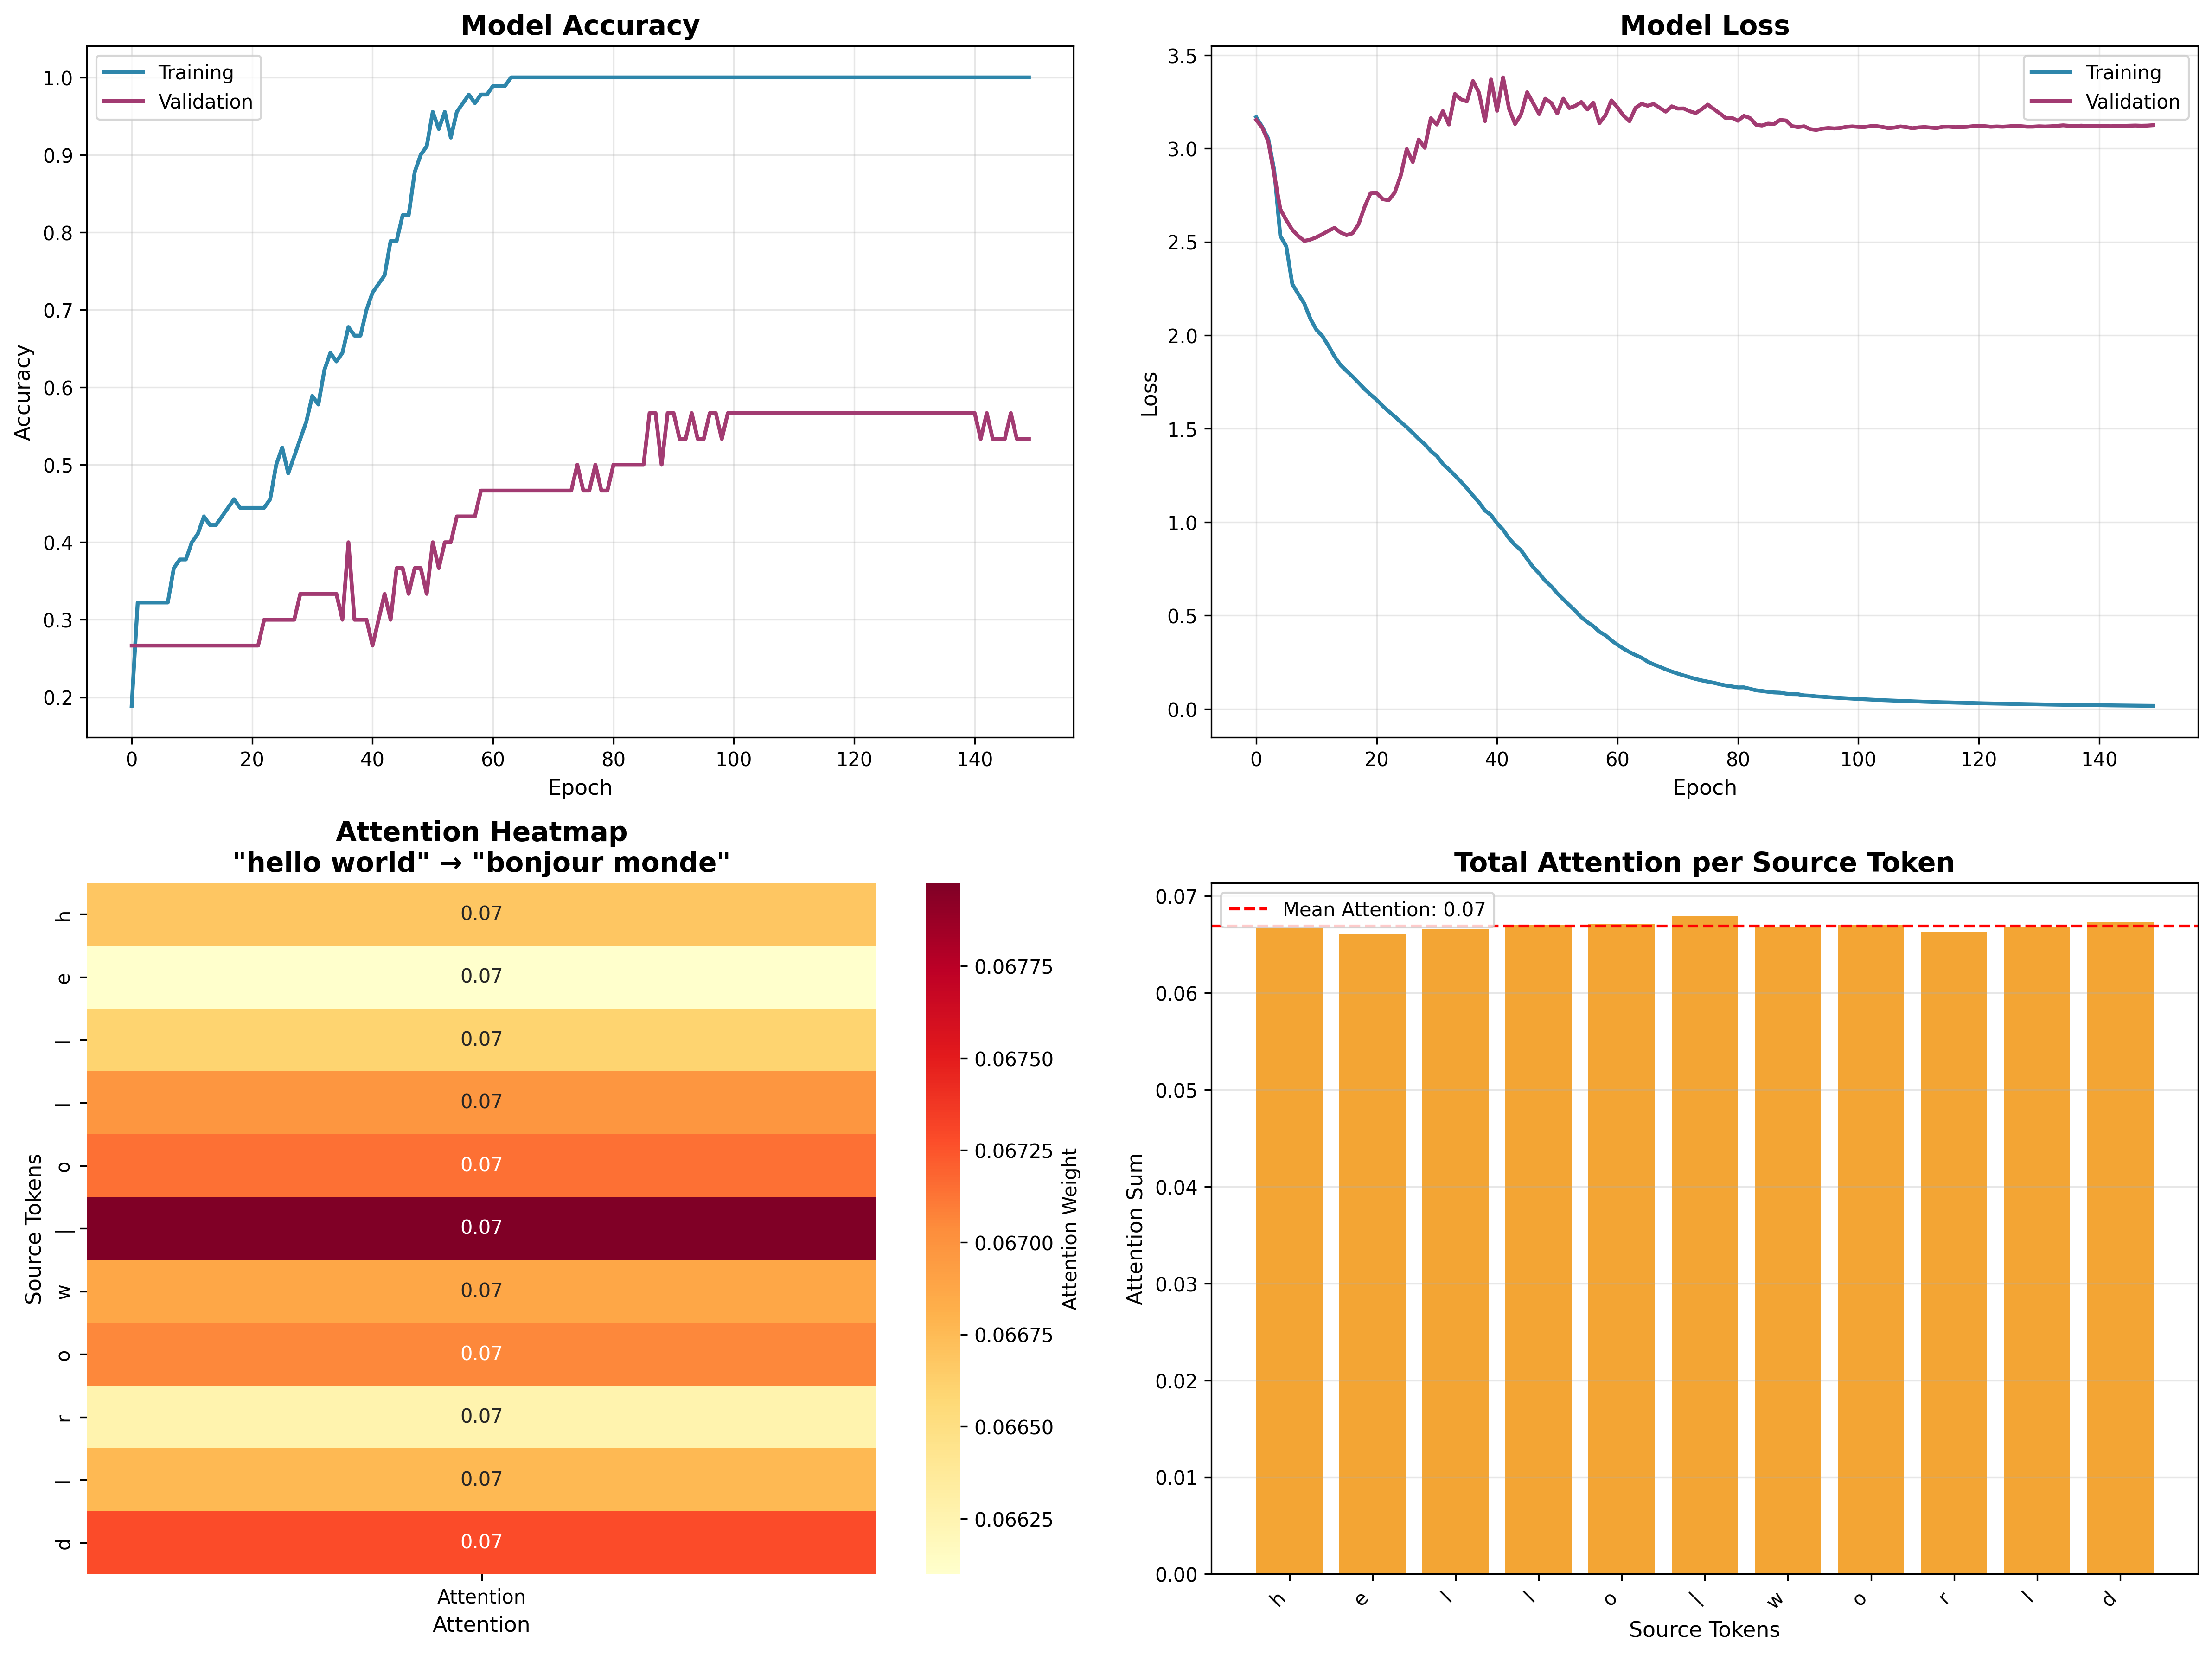

### Multiple Attention Heatmaps


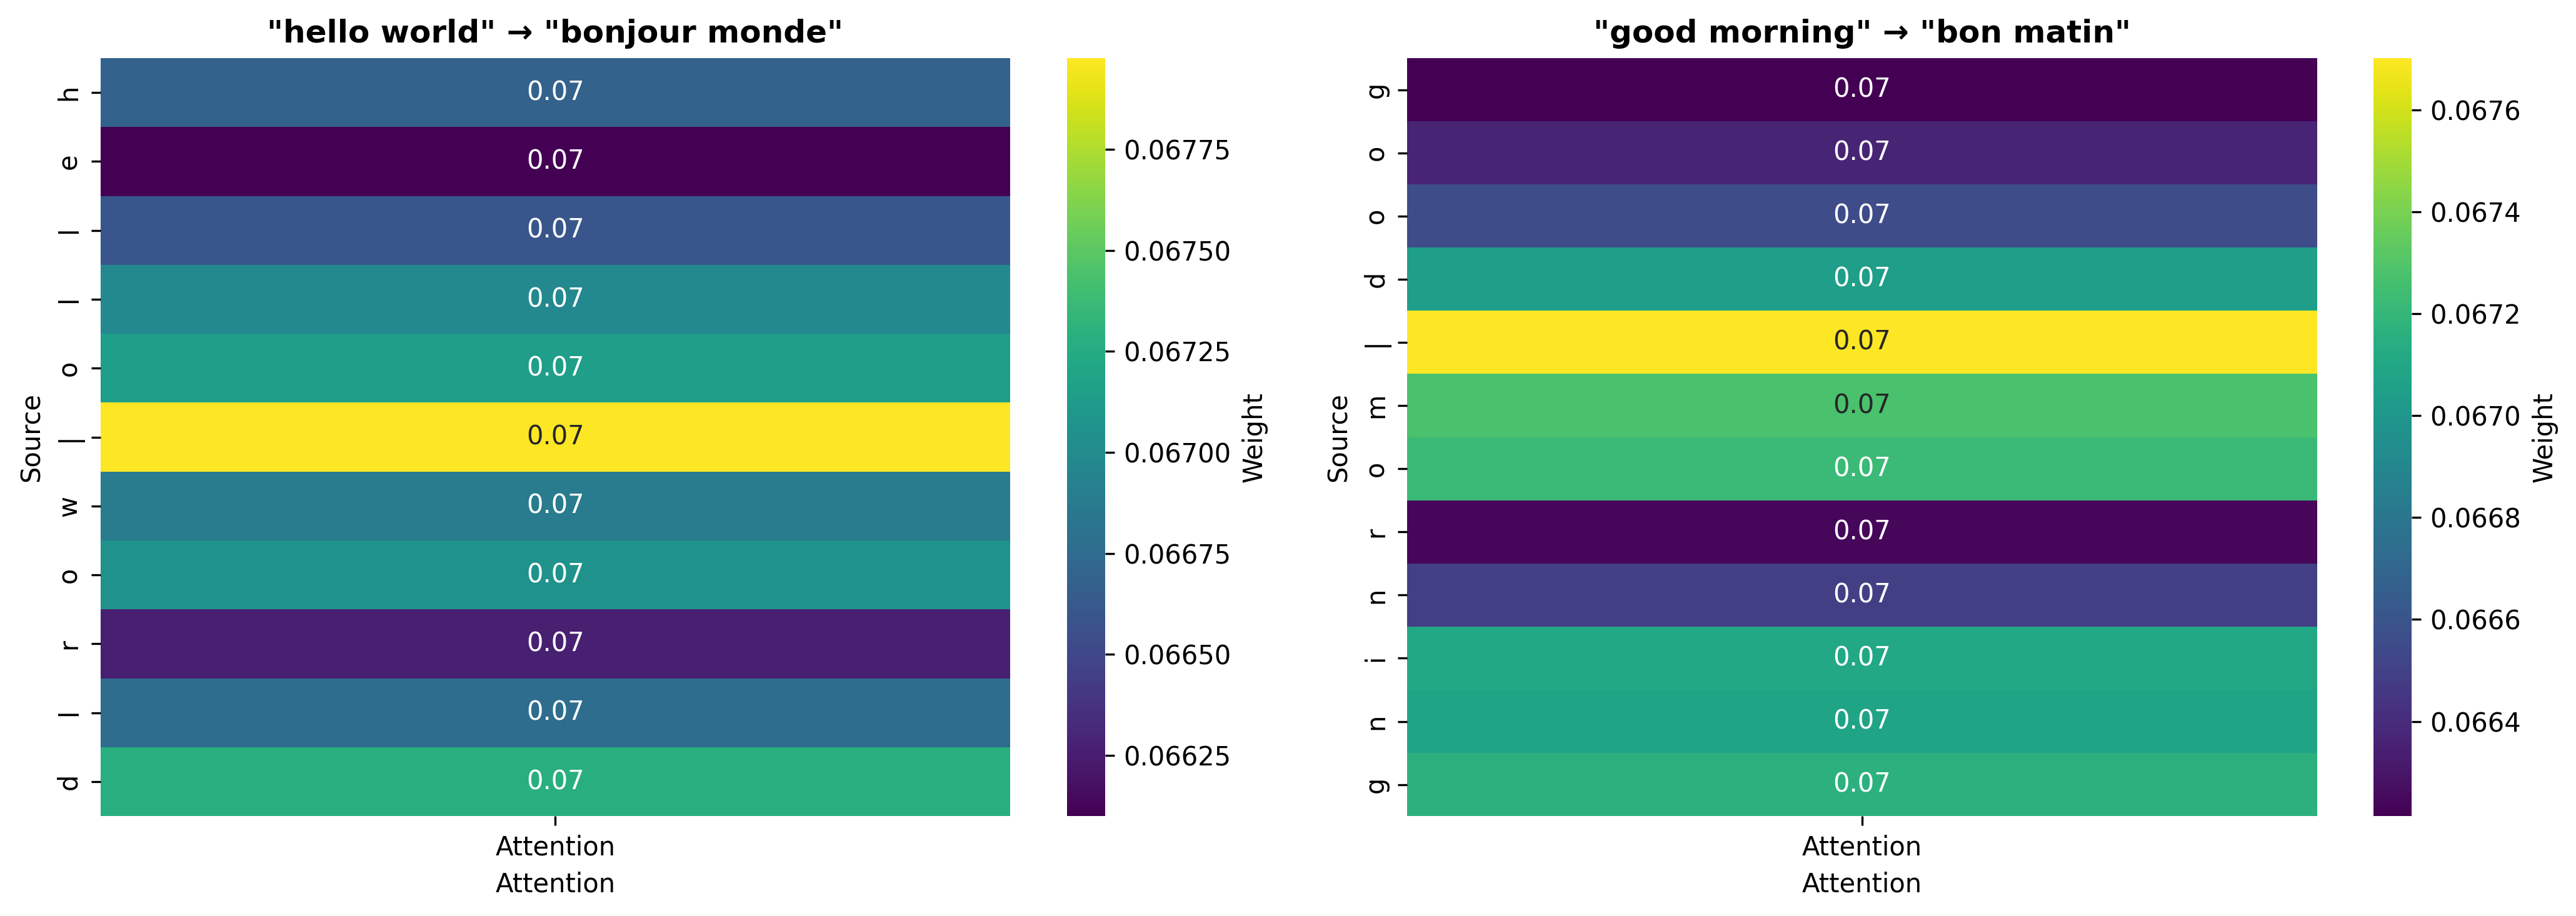

In [5]:
from IPython.display import Image, display

print("\n" + "-" * 60)
print("Displaying Visualizations")
print("-" * 60)

print("### Combined Attention Heatmap and Distribution")
display(Image('/content/lab6_attention_heatmaps.png'))

print("### Multiple Attention Heatmaps")
display(Image('/content/lab6_multiple_attention.png'))